In [1]:
import numpy as np
import torch
from torch.utils.data import TensorDataset,DataLoader,Dataset
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#from scipy.signal import butter, filtfilt
import torch.nn as nn
from torch import optim
#from scipy.io import loadmat




In [2]:
def segment_signal(signal, seg_len=400, step=200):
    segments = []
    for start in range(0, len(signal) - seg_len, step):
        segments.append(signal[start:start+seg_len])
    return segments


In [3]:
import os
import numpy as np

def load_signals(folder):
    signals = []
    for file in sorted(os.listdir(folder)):
        if file.endswith(".txt"):
            sig = np.loadtxt(os.path.join(folder, file))
            signals.append(sig)
    return signals

signals_Z = load_signals("Z")
signals_O = load_signals("O")
signals_S = load_signals("S")

print(len(signals_Z), len(signals_O), len(signals_S))


100 100 100


In [4]:
X = []
y = []

for sig in signals_Z:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(0)

for sig in signals_O:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(1)

for sig in signals_S:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(2)

X = np.array(X)
y = np.array(y)

print("Before reshape:", X.shape)
print("Labels:", np.unique(y, return_counts=True))

# تبدیل به (samples, 400, 1)
X = X[:, :, np.newaxis]

print("Final shape:", X.shape)



Before reshape: (5700, 400)
Labels: (array([0, 1, 2]), array([1900, 1900, 1900]))
Final shape: (5700, 400, 1)


In [5]:
from sklearn.model_selection import train_test_split


Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Xtrain, Xvalid, ytrain, yvalid = train_test_split(
    Xtrain, ytrain,
    test_size=0.15,
    random_state=42,
    stratify=ytrain
)

print("Train:", Xtrain.shape)
print("Valid:", Xvalid.shape)
print("Test :", Xtest.shape)



Train: (3876, 400, 1)
Valid: (684, 400, 1)
Test : (1140, 400, 1)


In [6]:
# tensor
Xtrain_tensor = torch.tensor(Xtrain, dtype=torch.float32)
Xvalid_tensor = torch.tensor(Xvalid, dtype=torch.float32)
Xtest_tensor  = torch.tensor(Xtest, dtype=torch.float32)

ytrain_tensor = torch.tensor(ytrain, dtype=torch.long)
yvalid_tensor = torch.tensor(yvalid, dtype=torch.long)
ytest_tensor  = torch.tensor(ytest, dtype=torch.long)

train_ds = TensorDataset(Xtrain_tensor, ytrain_tensor)
valid_ds = TensorDataset(Xvalid_tensor, yvalid_tensor)
test_ds  = TensorDataset(Xtest_tensor, ytest_tensor)

batch_size = 16

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("DataLoader OK ✅")





DataLoader OK ✅


In [7]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNNClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.GRU(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.1 if num_layers > 1 else 0.0
        )

        self.d = 2  # چون bidirectional=True
        self.fc = nn.Linear(hidden_size * self.d, num_classes)

    def forward(self, x, h0=None):

        if h0 is None:
            h_prev = torch.zeros(
                self.num_layers * self.d,
                x.size(0),
                self.hidden_size,
                device=x.device
            )
        else:
            h_prev = h0

        out, ht = self.rnn(x, h_prev)

        h_forward = ht[-2, :, :]
        h_backward = ht[-1, :, :]
        output = torch.cat((h_forward, h_backward), dim=1)

        out = self.fc(output)
        return out


In [8]:
model = RNNClassifier(input_size=1,
                      hidden_size=128,
                      num_layers=2,
                      num_classes=3)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model ready ✅")


Model ready ✅


In [9]:

# train and record metrics for plotting
num_epochs = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):

    # ========= TRAIN =========
    model.train()
    train_loss_sum = 0.0
    correct_train = 0
    total_train = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == y_batch).sum().item()
        total_train += y_batch.size(0)

    avg_train_loss = train_loss_sum / len(train_loader)
    train_acc = correct_train / total_train

    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # ========= VALIDATION =========
    model.eval()
    val_loss_sum = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
       for x_batch, y_batch in valid_loader:

            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)

            val_loss_sum += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == y_batch).sum().item()
            total_val += y_batch.size(0)
            
    avg_val_loss = val_loss_sum / len(valid_loader)

    val_acc = correct_val / total_val

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")



Epoch [1/10] Train Loss: 0.5451 | Val Loss: 0.4057
Epoch [2/10] Train Loss: 0.3343 | Val Loss: 0.2971
Epoch [3/10] Train Loss: 0.2986 | Val Loss: 0.2550
Epoch [4/10] Train Loss: 0.2645 | Val Loss: 0.2417
Epoch [5/10] Train Loss: 0.2418 | Val Loss: 0.2753
Epoch [6/10] Train Loss: 0.2261 | Val Loss: 0.2945
Epoch [7/10] Train Loss: 0.2115 | Val Loss: 0.2250
Epoch [8/10] Train Loss: 0.2053 | Val Loss: 0.2084
Epoch [9/10] Train Loss: 0.1832 | Val Loss: 0.2112
Epoch [10/10] Train Loss: 0.1892 | Val Loss: 0.2209


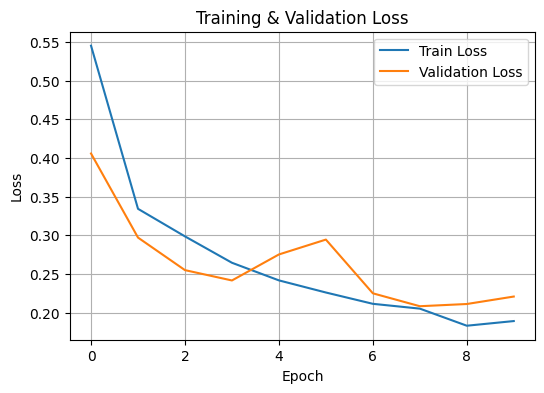

In [10]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


Test Accuracy: 90.26%
              precision    recall  f1-score   support

           0       0.82      0.92      0.86       380
           1       0.90      0.80      0.85       380
           2       1.00      0.99      1.00       380

    accuracy                           0.90      1140
   macro avg       0.91      0.90      0.90      1140
weighted avg       0.91      0.90      0.90      1140



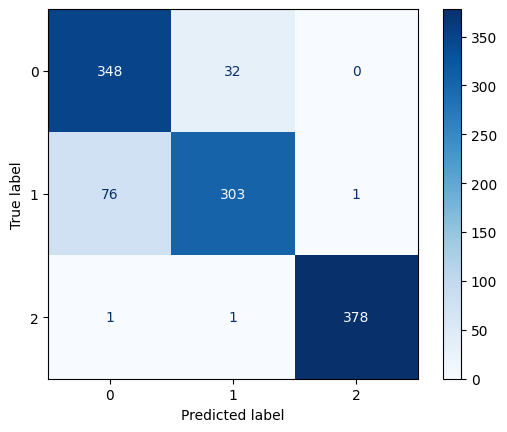

In [11]:
# Evaluation (total accuracy, each class accuracy, confusion matrix plot)
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    y_pred=[]
    y_true=[]
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_pred.extend(predicted.numpy())
        y_true.extend(labels.numpy())
    accuracy = 100 * correct / total

    print(f'Test Accuracy: {accuracy:.2f}%')
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
    cm= confusion_matrix(y_true,y_pred)
    disp= ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    print(classification_report(y_true,y_pred))
    plt.show()
    
    
    
    